In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [2]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
%aimport nosharing
%aimport testsym
# %aimport vareps
# %aimport baseline
# ^can be taken into usee when needed; they're in a separate folder, need to be taken out first


Parameter values

In [25]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5
sigma = 0.5

# Baseline model

In [142]:
df_regime = model.regime_map(gamma=0, mu=0.75, sigma=0.5)

In [163]:
def find_mixed_regions(df_regime):
    mixed = df_regime[df_regime["regime"].isin(["AN"])]
    return mixed[["eps", "s"]]

In [164]:
mixed = find_mixed_regions(df_regime)
print(mixed)
mixed.count()


          eps         s
89   0.178571  0.200000
103  0.214286  0.185721
104  0.214286  0.200000
117  0.250000  0.171443
118  0.250000  0.185721
119  0.250000  0.200000
131  0.285714  0.157164
132  0.285714  0.171443
133  0.285714  0.185721
134  0.285714  0.200000
146  0.321429  0.157164
147  0.321429  0.171443
148  0.321429  0.185721
149  0.321429  0.200000
160  0.357143  0.142886
161  0.357143  0.157164
162  0.357143  0.171443
163  0.357143  0.185721
164  0.357143  0.200000
175  0.392857  0.142886
176  0.392857  0.157164
177  0.392857  0.171443
178  0.392857  0.185721
179  0.392857  0.200000
189  0.428571  0.128607
190  0.428571  0.142886
191  0.428571  0.157164
192  0.428571  0.171443
193  0.428571  0.185721
194  0.428571  0.200000
204  0.464286  0.128607
205  0.464286  0.142886
206  0.464286  0.157164
207  0.464286  0.171443
208  0.464286  0.185721
209  0.464286  0.200000
219  0.500000  0.128607
220  0.500000  0.142886
221  0.500000  0.157164
222  0.500000  0.171443
223  0.500000  0

eps    42
s      42
dtype: int64

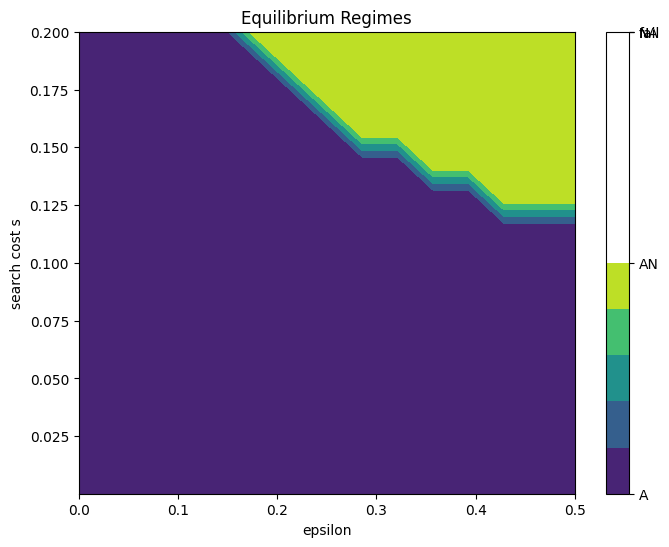

In [143]:
model.plot_regime_map(df_regime,     eps_grid = np.linspace(0.0, 0.5, 15), s_grid = np.linspace(0.0001, 0.2, 15))

# Variable Epsilon

$\mu=0.75$ - variable epsilon in play.

In [123]:
mu = 0.75
gamma = 0
results_vareps = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_vareps = pd.DataFrame(results_vareps)
df_vareps["Theta"] = df_vareps["Theta"].clip(0, 1)

# Figures to compare baseline and variable epsilon
**Colorbar**

In [24]:
p1_grid = np.linspace(0.01, 0.99, 10)
p2_grid = np.linspace(0.01, 0.99, 10)
def theta_price(eps, s, p, sigma):
    for p in p1_grid:
        theta = testsym.theta_num(eps, s, p, sigma)
        print(f"p1: {p}, Theta: {theta}")

theta_price(eps=0.5, s=0.19, p=p1_grid, sigma=0.5)

p1: 0.01, Theta: 0.11644140029689765
p1: 0.11888888888888888, Theta: 0.11644140029689765
p1: 0.22777777777777777, Theta: 0.11644140029689765
p1: 0.33666666666666667, Theta: 0.11644140029689765
p1: 0.44555555555555554, Theta: 0.11114419921077867
p1: 0.5544444444444444, Theta: 0.11114419921077856
p1: 0.6633333333333333, Theta: 0.12300098933423537
p1: 0.7722222222222221, Theta: 0.14671456958114892
p1: 0.8811111111111111, Theta: 0.1822849399515193
p1: 0.99, Theta: 0.13


In [9]:
p1_grid = np.linspace(0.01, 0.99, 10)
p2_grid = np.linspace(0.01, 0.99, 10)
def theta_price(p1, p2, eps, s, gamma, mu, sigma):
    for p1, p2 in zip(p1_grid, p2_grid):
        theta = model.Theta_star(p1, p2, eps, s, gamma, mu, sigma)
        print(f"p1: {p1}, p2: {p2}, Theta: {theta}")

theta_price(p1_grid, p2_grid, eps=0.5, s=0.19, gamma=0, mu = 0.5, sigma=0.5)

p1: 0.01, p2: 0.01, Theta: 0.11644140029689765
p1: 0.11888888888888888, p2: 0.11888888888888888, Theta: 0.11644140029689765
p1: 0.22777777777777777, p2: 0.22777777777777777, Theta: 0.11644140029689765
p1: 0.33666666666666667, p2: 0.33666666666666667, Theta: 0.11644140029689765
p1: 0.44555555555555554, p2: 0.44555555555555554, Theta: 0.11114419921077867
p1: 0.5544444444444444, p2: 0.5544444444444444, Theta: 0.11114419921077856
p1: 0.6633333333333333, p2: 0.6633333333333333, Theta: 0.12300098933423537
p1: 0.7722222222222221, p2: 0.7722222222222221, Theta: 0.14671456958114892
p1: 0.8811111111111111, p2: 0.8811111111111111, Theta: 0.1822849399515193
p1: 0.99, p2: 0.99, Theta: 0.13



Baseline

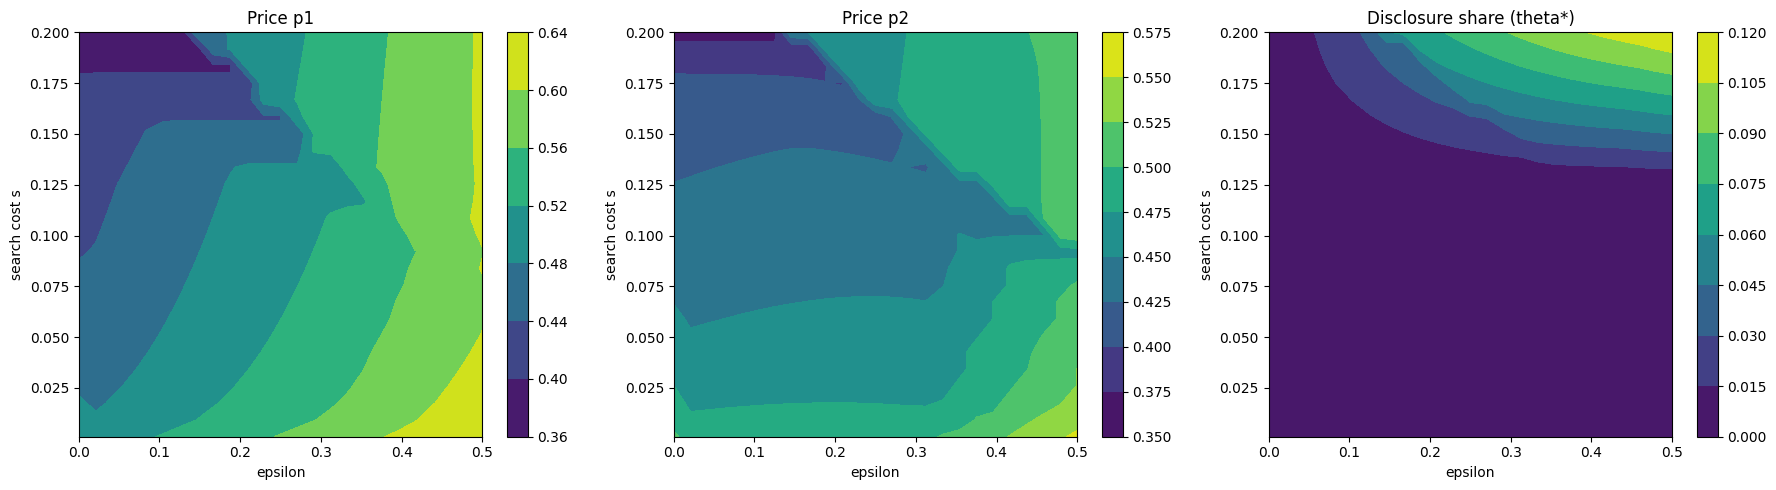

In [124]:
model.plot_colorblock(df_vareps, eps_grid, s_grid)

Variable epsilon

**Separate cases: functions of $\varepsilon$**

In [30]:
# Shared parameters
eps_grid = np.linspace(0.0, 0.5, 25)
s_values = [0.1, 0.15, 0.2]
p1_init, p2_init = 0.5, 0.5

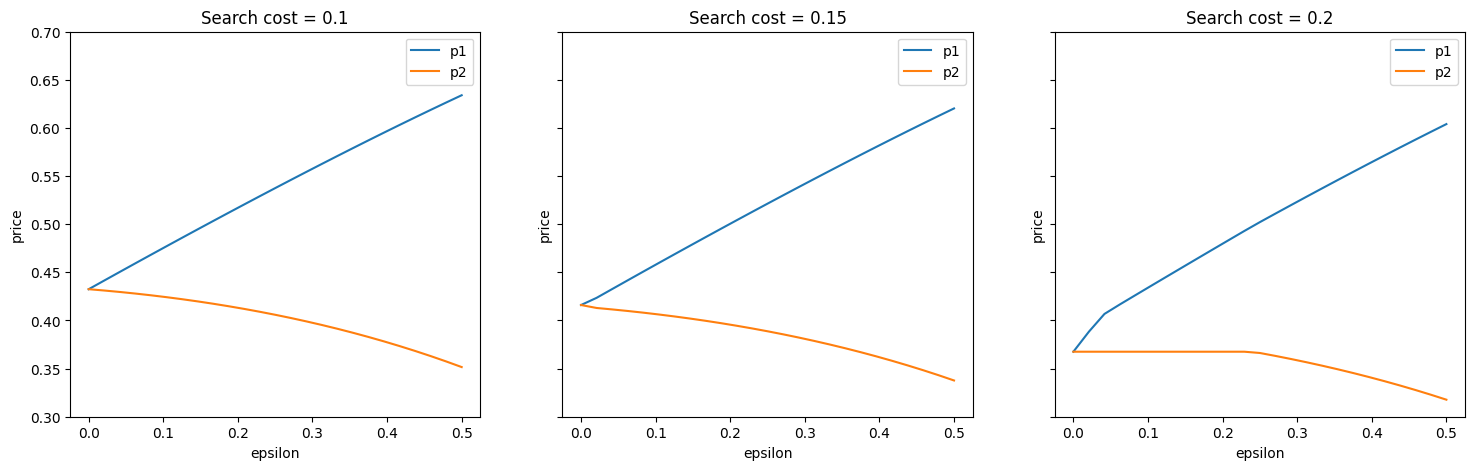

In [31]:
# baseline
gamma = 0
mu = 1
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

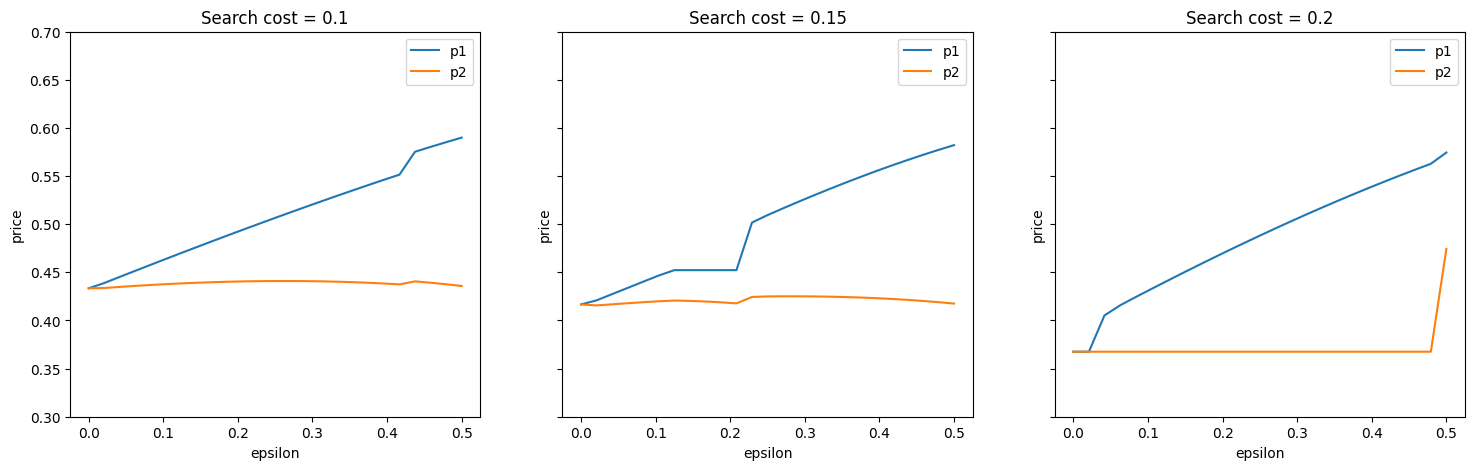

In [32]:
# variable epsilon
gamma = 0
mu = 0.75
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

# Baseline with naïvete

In [55]:
# Define parameter cases #
gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.1, 0.1),
    (0.2, 0.1),
    (0.2, 0.2),
    (0.2, 0.3)
]

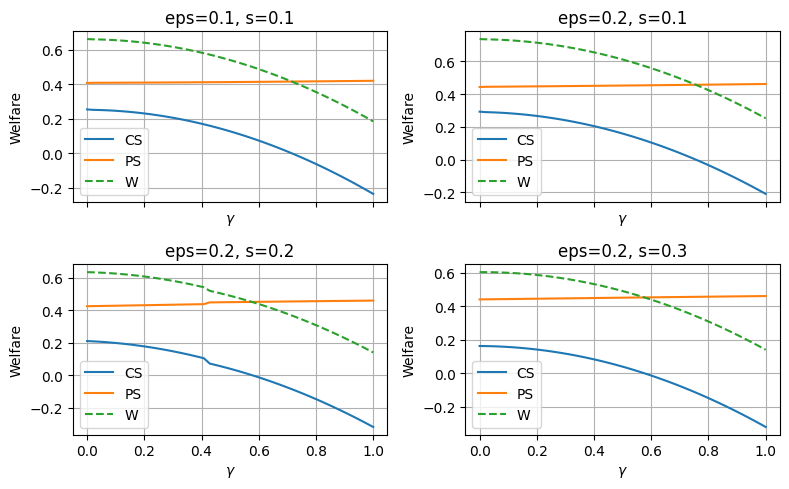

In [56]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

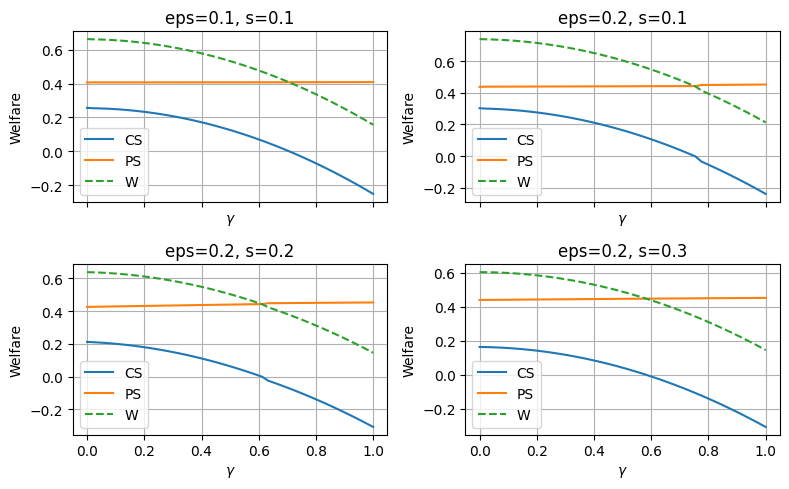

In [57]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

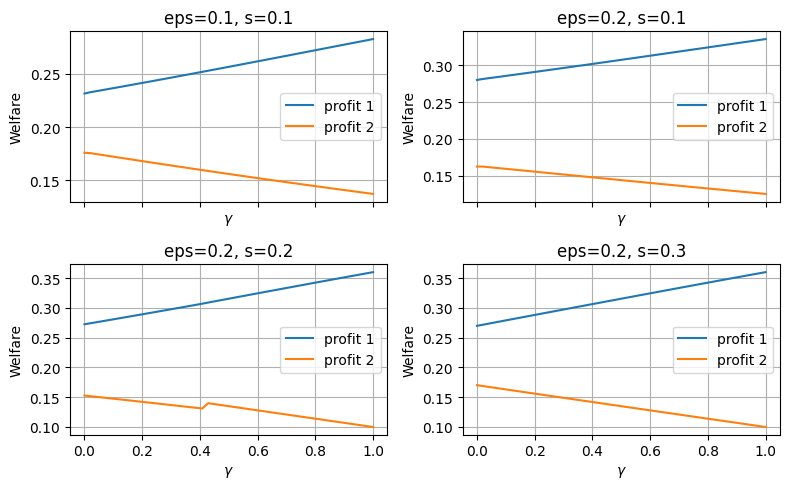

In [58]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

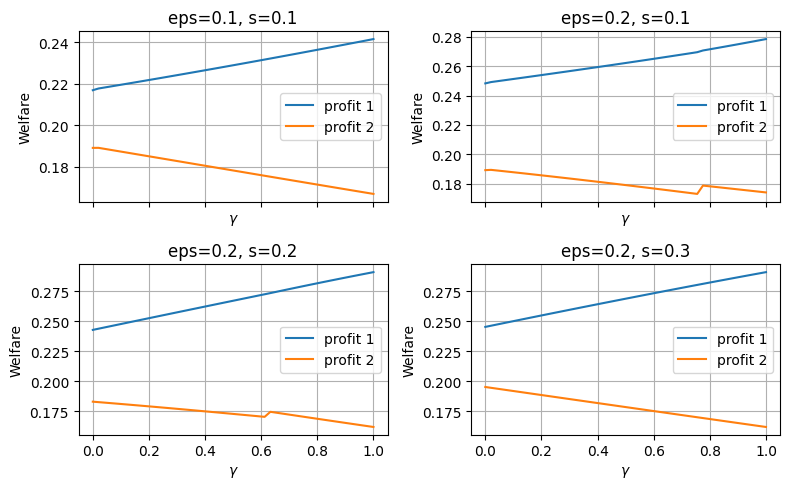

In [59]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [60]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
results_nosharing = []
p1_init, p2_init = 0.5, 0.5

In [166]:
eps, s = 0.2, 0.15
mu = 1
p1, p2, converged = nosharing.solve_equilibrium(eps, s, mu)
check = nosharing.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [167]:
eps, s = 0.2, 0.15
p1, p2, converged = ekstra.solve_equilibrium(eps, s)
check = ekstra.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [33]:
def compute_outcomes(eps, s, mu, sigma):

    results = {}

    # --- No sharing ---
    p1_ns, p2_ns, _ = nosharing.solve_equilibrium(eps, s, mu)
    pi1_ns = nosharing.profit1(p1_ns, p2_ns, eps, s, mu)
    pi2_ns = nosharing.profit2(p1_ns, p2_ns, eps, s, mu)

    results["No Sharing"] = {
        "p1": p1_ns,
        "p2": p2_ns,
        "pi1": pi1_ns,
        "pi2": pi2_ns,
        "CS": nosharing.consumer_surplus(p1_ns, p2_ns, eps, s, mu),
        "PS": pi1_ns + pi2_ns,
        "W": nosharing.total_welfare(p1_ns, p2_ns, eps, s, mu)
    }

    # --- Sharing, rational ---
    p1_r, p2_r, _ = model.solve_equilibrium(eps, s, gamma=0, mu=mu, sigma=sigma)
    pi1_r = model.profit1(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)
    pi2_r = model.profit2(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)

    results["Sharing (γ=0)"] = {
        "p1": p1_r,
        "p2": p2_r,
        "pi1": pi1_r,
        "pi2": pi2_r,
        "CS": model.consumer_surplus(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma),
        "PS": pi1_r + pi2_r,
        "W": model.total_welfare(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)
    }

    # --- Sharing, naive ---
    p1_n, p2_n, _ = model.solve_equilibrium(eps, s, gamma=0.3, mu=mu, sigma=sigma)
    pi1_n = model.profit1(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)
    pi2_n = model.profit2(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)

    results["Sharing (γ=0.3)"] = {
        "p1": p1_n,
        "p2": p2_n,
        "pi1": pi1_n,
        "pi2": pi2_n,
        "CS": model.consumer_surplus(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma),
        "PS": pi1_n + pi2_n,
        "W": model.total_welfare(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)
    }

    return pd.DataFrame(results).T

In [201]:
df_eps = compute_outcomes(eps=0.5, s=0.2, mu=0.5, sigma=0.5)
print(df_eps.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.552  0.552  0.270  0.270  0.387  0.540  0.928
Sharing (γ=0)    0.569  0.569  0.271  0.271  0.370  0.542  0.913
Sharing (γ=0.3)  0.677  0.677  0.283  0.283  0.074  0.567  0.641


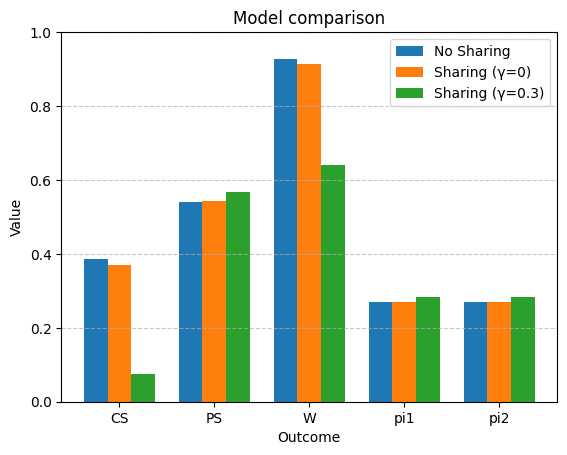

In [202]:
model.plot_welfare_comparison(df_eps)

# Symmetric model

In [195]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
gamma = 0
mu = 0.5
sigma = 0.5
prev_p1, prev_p2 = 0.5, 0.5
results_sym = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_sym = pd.DataFrame(results_sym)

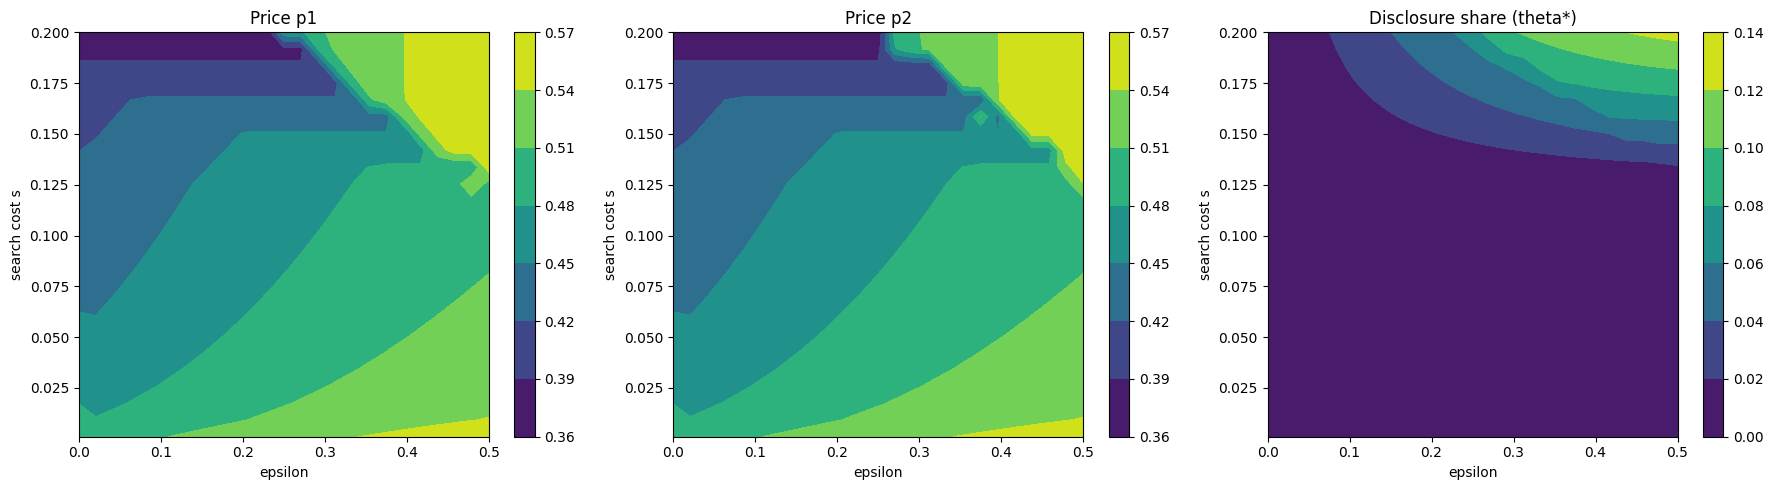

In [196]:
model.plot_colorblock(df_sym, eps_grid, s_grid)